In [7]:
from google.colab import files
uploaded = files.upload()

Saving website_traffic.csv to website_traffic.csv


In [8]:
import pandas as pd

df = pd.read_csv("website_traffic.csv")
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [9]:
df.isnull().sum()

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [10]:
df = df.dropna(subset=['country', 'city'])

In [11]:
df['artist'] = df['artist'].fillna('Unknown')
df['album'] = df['album'].fillna('Unknown')
df['track'] = df['track'].fillna('Unknown')

In [30]:
entry = df.sort_values('date').groupby('linkid').first()
entry['track'].value_counts().head(5)

,count
track,
Baby Shark,5
Happy Birthday,4
Freestyle,4
Okay,4
Heat Waves,4


In [31]:
exit = df.sort_values('date').groupby('linkid').last()
exit['track'].value_counts().head(5)

,count
track,
Baby Shark,5
Happy Birthday,4
Freestyle,4
Okay,4
Heat Waves,4


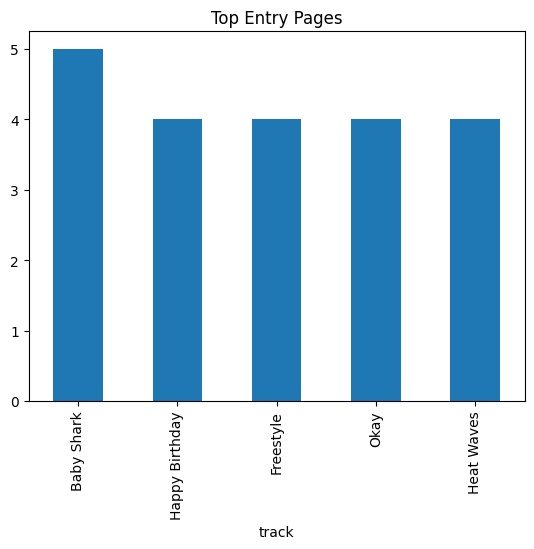

In [32]:
entry['track'].value_counts().head(5).plot(kind='bar')
plt.title("Top Entry Pages")
plt.show()

In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df = df.drop_duplicates()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122562 entries, 0 to 226274
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    122562 non-null  object        
 1   date     122562 non-null  datetime64[ns]
 2   country  122562 non-null  object        
 3   city     122562 non-null  object        
 4   artist   122562 non-null  object        
 5   album    122562 non-null  object        
 6   track    122562 non-null  object        
 7   isrc     116257 non-null  object        
 8   linkid   122562 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 9.4+ MB


In [15]:
df['linkid'].nunique()

3839

In [16]:
df[['country', 'city']].drop_duplicates().shape[0]

12477

In [17]:
session_counts = df.groupby('linkid').size()
session_counts.head()

,0
linkid,
00073307-ae96-5089-a117-4783afb42f8e,2
00126b32-0c35-507b-981c-02c80d2aa8e7,4
0018cfff-50a1-5984-9715-01ef2d11a49a,1
0033934b-5d16-5a06-af58-d087bcdd3680,1
0034d6cf-3bd8-5ffe-aafc-b3959fc48608,1


In [18]:
bounce_sessions = (session_counts == 1).sum()
total_sessions = session_counts.count()

bounce_rate = (bounce_sessions / total_sessions) * 100
bounce_rate

np.float64(35.58218286011982)

In [19]:
df['track'].value_counts().head(10)

,count
track,
Jalebi Baby,8288
Beautiful,4037
Beautiful Day,3951
Late At Night,3059
ily (i love you baby) (feat. Emilee),2956
Calabria (feat. Lujavo & Nito-Onna),2865
So Pretty,2827
Candy Shop,2397
Summer of Love (Shawn Mendes & Tainy),2108


In [20]:
df['artist'].value_counts().head(10)

,count
artist,
Tesher,8288
Anne-Marie,4029
Tundra Beats,3951
Roddy Ricch,3107
Olivia Rodrigo,3037
"Surf Mesa, Emilee",2956
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",2865
Reyanna Maria,2672
PinkPantheress,2446


In [21]:
df['country'].value_counts().head(10)

,count
country,
United States,28664
India,18689
France,10565
Saudi Arabia,7682
United Kingdom,5095
Germany,4017
Canada,2784
Pakistan,2633
Iraq,2444


In [22]:
df.groupby('date').size().head()

,0
date,
2021-08-19,21156
2021-08-20,18536
2021-08-21,16701
2021-08-22,16927
2021-08-23,16412


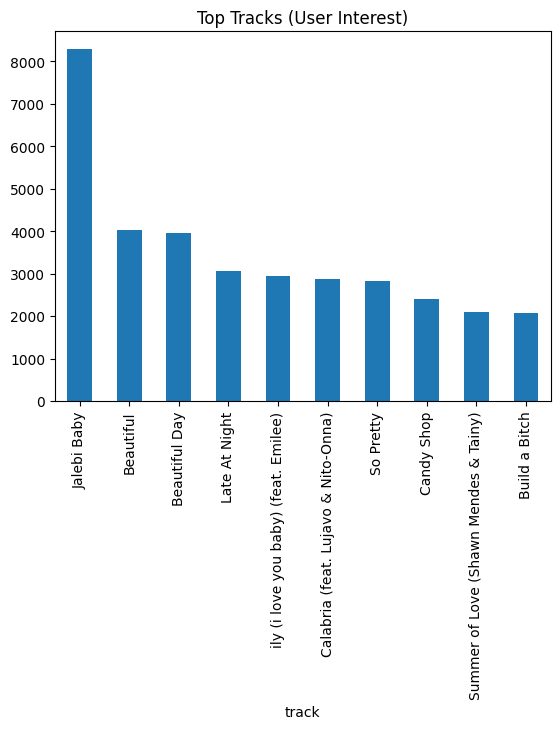

In [23]:
df['track'].value_counts().head(10).plot(kind='bar')
plt.title("Top Tracks (User Interest)")
plt.show()

In [24]:
df['country'].value_counts().head(5)

,count
country,
United States,28664
India,18689
France,10565
Saudi Arabia,7682
United Kingdom,5095


In [25]:
import sqlite3

conn = sqlite3.connect("traffic.db")
df.to_sql("traffic", conn, if_exists="replace", index=False)

122562

In [26]:
query = "SELECT COUNT(DISTINCT linkid) AS total_sessions FROM traffic"
pd.read_sql(query, conn)

,total_sessions
0,3839


In [27]:
query = """
SELECT
    (SUM(CASE WHEN cnt = 1 THEN 1 ELSE 0 END) * 100.0) / COUNT(*) AS bounce_rate
FROM (
    SELECT linkid, COUNT(*) as cnt
    FROM traffic
    GROUP BY linkid
)
"""
pd.read_sql(query, conn)

,bounce_rate
0,35.582183


In [28]:
query = """
SELECT track, COUNT(*) as total
FROM traffic
GROUP BY track
ORDER BY total DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,track,total
0,Jalebi Baby,8288
1,Beautiful,4037
2,Beautiful Day,3951
3,Late At Night,3059
4,ily (i love you baby) (feat. Emilee),2956


In [29]:
query = """
SELECT country, COUNT(*) as users
FROM traffic
GROUP BY country
ORDER BY users DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,country,users
0,United States,28664
1,India,18689
2,France,10565
3,Saudi Arabia,7682
4,United Kingdom,5095


**Final Insights & Recommendations**

**Recommendations to Improve Conversions for Alfido Tech**

1.Improve the landing page experience by enhancing UI/UX and reducing page load time to minimize bounce rate.

2.Reduce bounce rate by adding related content suggestions and interactive elements to keep users engaged.

3.Focus on high-performing content such as “Jalebi Baby” and promote similar tracks to increase user interaction.

4.Target high-traffic regions like the United States and India with personalized marketing strategies.

5.Increase user engagement by introducing features like playlists, autoplay, and personalized recommendations.
